<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/final_project_edit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-04-23/tidy_anime.csv"
df_unique = pd.read_csv(url)

df_unique = df.dropna(subset=["synopsis"])
df_unique = df.reset_index(drop=True)
df_unique = df.drop_duplicates(subset="animeID").copy()

df_unique.head()

,animeID,name,title_english,title_japanese,title_synonyms,type,source,producers,genre,studio,...,scored_by,rank,popularity,members,favorites,synopsis,background,premiered,broadcast,related
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Action,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
6,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"[""Cowboy Bebop: Knockin' on Heaven's Door""]",Movie,Original,Sunrise,Action,Bones,...,120243,164,449,197791,776,"Another day, another bounty—such is the life o...",NaN,NaN,NaN,"{'Parent story': [{'mal_id': 1, 'type': 'anime..."
16,6,Trigun,Trigun,トライガン,[],TV,Manga,Victor Entertainment,Action,Madhouse,...,212537,255,146,408548,10432,"Vash the Stampede is the man with a $$60,000,0...",The Japanese release by Victor Entertainment h...,Spring 1998,Thursdays at 01:15 (JST),"{'Adaptation': [{'mal_id': 703, 'type': 'manga..."
22,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN,['WHR'],TV,Original,Bandai Visual,Action,Sunrise,...,32837,2371,1171,79397,537,Witches are individuals with special powers li...,NaN,Summer 2002,Tuesdays at Unknown,{}
28,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,['Adventure King Beet'],TV,Manga,TV Tokyo,Adventure,Toei Animation,...,4894,3544,3704,11708,14,It is the dark century and the people are suff...,NaN,Fall 2004,Thursdays at 18:30 (JST),"{'Adaptation': [{'mal_id': 1348, 'type': 'mang..."


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df_unique["clean_synopsis"] = df_unique["synopsis"].apply(clean_text)

In [ ]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df_unique["sentiment"] = df_unique["clean_synopsis"].apply(lambda x: sia.polarity_scores(x)["compound"])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
fig = px.histogram(
    df_unique,
    x="sentiment",
    nbins=20,
    title="Sentiment Distribution of Anime Synopses"
)

fig.show()

In [ ]:
vectorizer = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_topics = vectorizer.fit_transform(df_unique["clean_synopsis"])

In [ ]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1
['student', 'love', 'friends', 'day', 'new', 'life', 'girl', 'high', 'source', 'school']

Topic 2
['time', 'new', 'game', 'official', 'ann', 'world', 'song', 'video', 'music', 'source']

Topic 3
['movie', 'episodes', 'manga', 'animation', 'film', 'source', 'short', 'episode', 'anime', 'series']

Topic 4
['cat', 'princess', 'life', 'magic', 'named', 'ann', 'girl', 'magical', 'world', 'source']

Topic 5
['years', 'war', 'rewrite', 'written', 'mal', 'new', 'life', 'earth', 'world', 'source']


In [ ]:
X = df_unique["clean_synopsis"]
y = df_unique["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Movie       0.59      0.56      0.58       470
       Music       0.96      0.77      0.86       207
         ONA       0.64      0.34      0.44       259
         OVA       0.59      0.42      0.49       471
     Special       0.78      0.61      0.68       380
          TV       0.58      0.88      0.70       836

    accuracy                           0.64      2623
   macro avg       0.69      0.59      0.62      2623
weighted avg       0.65      0.64      0.62      2623



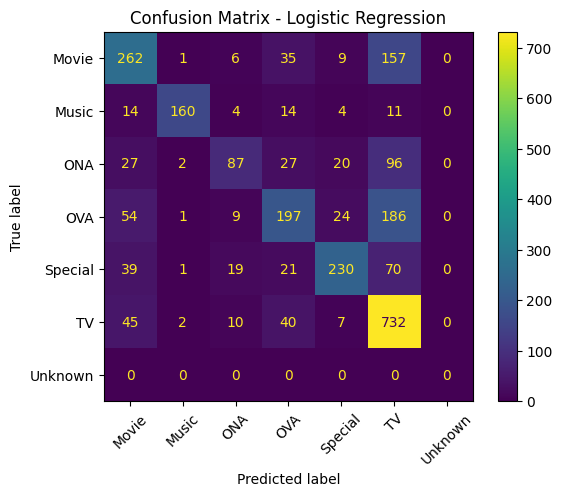

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
print(df.shape)
print(df_unique.shape)

(76362, 28)
(13114, 30)
